**Therory Questions**


1. **What is a Decision Tree, and how does it work**
    - A flowchart-like model that splits data based on feature conditions to predict outcomes.

2. **What are impurity measures in Decision Trees**
   - Metrics like Gini and Entropy used to measure how mixed the target classes are in a node.

3. **What is the mathematical formula for Gini Impurity**
   - Gini = 1 − ∑(pᵢ²), where pᵢ is the probability of class i.

4. **What is the mathematical formula for Entropy**
   - Entropy = − ∑(pᵢ × log₂(pᵢ)), where pᵢ is the probability of class i.

5. **What is Information Gain, and how is it used in Decision Trees**
   - It measures the reduction in impurity after a split and is used to choose the best feature.

6. **What is the difference between Gini Impurity and Entropy**
  -  Both measure impurity, but Gini is faster to compute while Entropy is based on information theory.

7. **What is the mathematical explanation behind Decision Trees**
   - They use recursive binary splitting to minimize impurity in child nodes.

8. **What is Pre-Pruning in Decision Trees**
   - Stopping the tree from growing too deep based on conditions like max depth or min samples.

9. **What is Post-Pruning in Decision Trees**
  -  Allowing the tree to fully grow, then cutting back nodes that don’t improve performance.

10. **What is the difference between Pre-Pruning and Post-Pruning**
    Pre-pruning prevents overgrowth early, while post-pruning trims it after full training.

11. **What is a Decision Tree Regressor**
   - A decision tree model that predicts continuous numeric values instead of class labels.

12. **What are the advantages and disadvantages of Decision Trees**
    - Advantages: simple, interpretable, handles mixed data; Disadvantages: overfitting, unstable with small changes.

13. **How does a Decision Tree handle missing values**
    - By skipping, imputing, or routing instances based on available features.

14. **How does a Decision Tree handle categorical features**
    - By splitting on each category or grouping them based on impurity reduction.

15. **What are some real-world applications of Decision Trees**
    - Used in credit scoring, medical diagnosis, fraud detection, customer churn, and loan approval.

---



In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,classification_report

In [2]:
#16. Write a Python program to train a Decision Tree Classifier on the Iris dataset and print the model accuracy*
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

data= load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
X=df
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)      

model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(acc)

1.0


In [3]:
#17* Write a Python program to train a Decision Tree Classifier using Gini Impurity as the criterion and print the feature importances*
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  

model=DecisionTreeClassifier(criterion='gini')
model.fit(X_train,y_train)
model.feature_importances_
#y_pred=model.predict(X_test)

array([0.48443794, 0.05217919, 0.46338287])

In [4]:
#18* Write a Python program to train a Decision Tree Classifier using Entropy as the splitting criterion and print the model accuracy*
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  

model=DecisionTreeClassifier(criterion='entropy')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
print(acc)

0.9


In [5]:
#19* Write a Python program to train a Decision Tree Regressor on a housing dataset and evaluate using Mean Squared Error (MSE)*
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
model=DecisionTreeRegressor()
df=pd.DataFrame(data.data,columns=data.feature_names)
X=df
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  
model.fit(X_train,y_train)
mse = mean_squared_error(y_test,model.predict(X_test))
print("Mean Squared Error (MSE)",mse)

Mean Squared Error (MSE) 0.4997330882305717


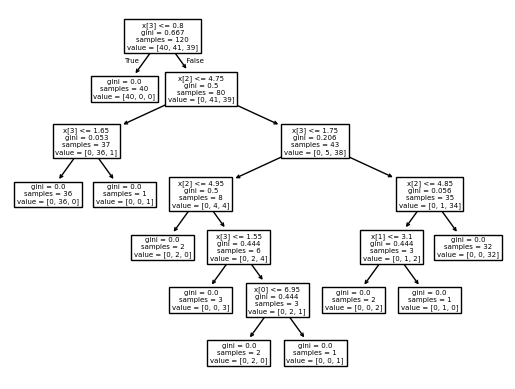

In [6]:
#20* Write a Python program to train a Decision Tree Classifier and visualize the tree using graphviz*
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

data= load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
X=df
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)      

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

tree.plot_tree(model)
plt.show()

In [7]:
#21* Write a Python program to train a Decision Tree Classifier with a maximum depth of 3 and compare its accuracy with a fully grown tree*
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  

model1=DecisionTreeClassifier()
model1.fit(X_train,y_train)

model2=DecisionTreeClassifier(max_depth=3)
model2.fit(X_train,y_train)

model1_accuracy=accuracy_score(y_test,model1.predict(X_test))
model2_accuracy=accuracy_score(y_test,model2.predict(X_test))
print("Decision Tree Classifier with a maximum depth of 3, Accuracy :",model1_accuracy)
print("accuracy with a fully grown tree",model2_accuracy)

Decision Tree Classifier with a maximum depth of 3, Accuracy : 0.895
accuracy with a fully grown tree 0.87


In [8]:
#22 Write a Python program to train a Decision Tree Classifier using min_samples_split=5 and compare its accuracy with a default tree*
model1=DecisionTreeClassifier(min_samples_split=5)
model1.fit(X_train,y_train)

model2=DecisionTreeClassifier()
model2.fit(X_train,y_train)


model1_accuracy=accuracy_score(y_test,model1.predict(X_test))
model2_accuracy=accuracy_score(y_test,model2.predict(X_test))
print("Decision Tree Classifier using min_samples_split=5, Accuracy :",model1_accuracy)
print("accuracy with a default tree",model2_accuracy)

Decision Tree Classifier using min_samples_split=5, Accuracy : 0.905
accuracy with a default tree 0.9


In [9]:
#23* Write a Python program to apply feature scaling before training a Decision Tree Classifier and compare its accuracy with unscaled data*

data= load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
X=df
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)      

#model with scaling
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train_scal=scale.fit_transform(X_train)
X_test_scal =scale.transform(X_test)
model1=DecisionTreeClassifier()
model1.fit(X_train_scal,y_train)
y_pred1=model1.predict(X_test_scal)
acc1=accuracy_score(y_test,y_pred1)
print("ACCURACY WITH FEATURE SCALING ",acc1)

#model without scaling
model2=DecisionTreeClassifier()
model2.fit(X_train,y_train)
y_pred2 =model2.predict(X_test)
acc2=accuracy_score(y_test,y_pred2)
print("aCCURAACY  WITH UNSCALED DATA ",acc2)

ACCURACY WITH FEATURE SCALING  1.0
aCCURAACY  WITH UNSCALED DATA  1.0


In [10]:
#24 Write a Python program to train a Decision Tree Classifier using One-vs-Rest (OvR) strategy for multiclass classification*

#data
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2) 

#model
from sklearn.multiclass import OneVsRestClassifier
classifier = DecisionTreeClassifier()
model= OneVsRestClassifier(estimator=classifier)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

0.895

In [11]:
#25* Write a Python program to train a Decision Tree Classifier and display the feature importance scores*
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  

model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(" feature importance scores ,",model.feature_importances_)


 feature importance scores , [0.51228827 0.02441817 0.46329356]


In [12]:
#26* Write a Python program to train a Decision Tree Regressor with max_depth=5 and compare its performance with an unrestricted tree*
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,n_features=3,n_informative=2,n_redundant=0,n_classes=3,n_clusters_per_class=1,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)  

#model 1 with depth 5 level
model1=DecisionTreeClassifier()
model1.fit(X_train,y_train)

#model 2 unrestricted
model2=DecisionTreeClassifier(max_depth=5)
model2.fit(X_train,y_train)

model1_accuracy=accuracy_score(y_test,model1.predict(X_test))
model2_accuracy=accuracy_score(y_test,model2.predict(X_test))
print("Decision Tree Classifier with a maximum depth of 5, Accuracy :",model1_accuracy)
print("accuracy with a fully grown tree",model2_accuracy)

Decision Tree Classifier with a maximum depth of 5, Accuracy : 0.885
accuracy with a fully grown tree 0.885


Cost Complexity Pruning (CCP) are : [0.         0.00923521 0.01269841 0.0185034  0.03972347 0.25028684
 0.31210884]


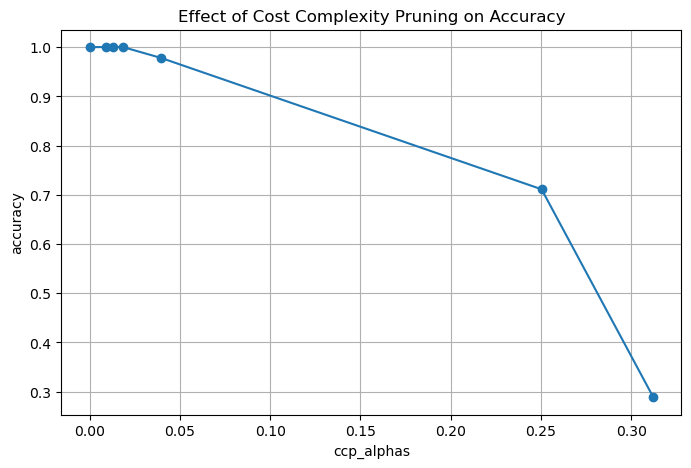

In [13]:
#27* Write a Python program to train a Decision Tree Classifier, apply Cost Complexity Pruning (CCP), and visualize its effect on accuracy*
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model=DecisionTreeClassifier()
path =model.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print("Cost Complexity Pruning (CCP) are :",ccp_alphas)

#we have 2 types to find the effect on accuracy --1.hyperparameter 2. manual check on every ccp
#i prefer manual check 
models=[]
for ccp in ccp_alphas:
    model=DecisionTreeClassifier(ccp_alpha=ccp)
    model.fit(X_train,y_train)
    models.append(model)
accuracy=[accuracy_score(y_test,model.predict(X_test)) for model in models]    

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas,accuracy,marker='o')
plt.xlabel("ccp_alphas")
plt.ylabel("accuracy")
plt.grid(True)
plt.title("Effect of Cost Complexity Pruning on Accuracy")
plt.show()

In [14]:
#28* Write a Python program to train a Decision Tree Classifier and evaluate its performance using Precision, Recall, and F1-Score*
from sklearn.metrics import precision_score,recall_score,f1_score
data =load_iris()
X,y=data.data,data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Precision ",precision_score(y_test,y_pred,average="micro"))
print("Recall ",recall_score(y_test,y_pred,average="micro"))
print(" F1-Score ",f1_score(y_test,y_pred,average="micro"))



Precision  1.0
Recall  1.0
 F1-Score  1.0


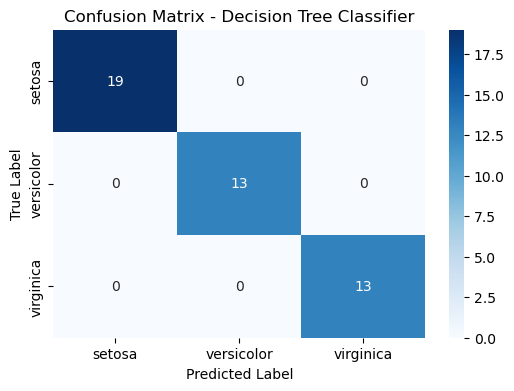

In [15]:
#29 Write a Python program to train a Decision Tree Classifier and visualize the confusion matrix using seaborn*
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
data =load_iris()
X,y=data.data,data.target
df=pd.DataFrame(data.data, columns=data.feature_names)
df["target"]=data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

# Plot original data
# plt.figure(figsize=(8, 6))
# sns.scatterplot(data=df, x="sepal length (cm)", y="petal length (cm)", hue='target')
# plt.title("Iris data (2 features)")
# plt.show()

cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [16]:
#30* Write a Python program to train a Decision Tree Classifier and use GridSearchCV to find the optimal values for max_depth and min_samples_split.
from sklearn.model_selection import GridSearchCV 
param={'max_depth':[2,3,4,5,8,10],
       'min_samples_split':[4,5,6,8,10,15,20]
      }
#data
data =load_iris()
X,y=data.data,data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model=GridSearchCV(DecisionTreeClassifier(),param_grid=param,cv=5,scoring="accuracy")
model.fit(X_train,y_train)

print("the optimal values for  min_samples_split",model.best_params_['min_samples_split'])
print("the optimal values for max_depth ",model.best_params_["max_depth"])

    

the optimal values for  min_samples_split 6
the optimal values for max_depth  4
